# This Notebook downloads Gaia data and excludes sources as defined in the Methods. This leaves stars in Gaia with accurate astrometry in the LMC which could potentially be runaways.

The purpose of this file: query Gaia around SN1987A, apply the same Gaia-quality and LMC-membership cuts, and save a clean candidate table.

# Expected runtime: 5-15 minutes on an average Desktop / Laptop

In [22]:
import sys
print(sys.executable)

C:\Users\bukow\anaconda3\envs\mygaia_win_min\python.exe


In [23]:
import sys
import subprocess

print(sys.executable)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "gaiadr3-zeropoint"
])

C:\Users\bukow\anaconda3\envs\mygaia_win_min\python.exe


0

In [24]:
from zero_point import zpt
zpt.load_tables()
print("works")

works


diagnostic cell to see which import is slow:

In [25]:
import time
import importlib

modules = [
    "numpy",
    "pandas",
    "matplotlib.pyplot",
    "os",
    "astroquery.gaia",
    "astropy",
    "astroquery",
    "zero_point.zpt",
    "input_files.Gaia_DR3_filtering",
    "input_files.Gaia_DR3_filtering_nozeropoint",
]

for module in modules:
    t0 = time.perf_counter()
    try:
        importlib.import_module(module)
        print(f"{module:45s} ok   {time.perf_counter() - t0:.2f} s")
    except Exception as e:
        print(f"{module:45s} FAIL {time.perf_counter() - t0:.2f} s")
        print(type(e).__name__, e)

numpy                                         ok   0.00 s
pandas                                        ok   0.00 s
matplotlib.pyplot                             ok   0.00 s
os                                            ok   0.00 s
astroquery.gaia                               ok   0.00 s
astropy                                       ok   0.00 s
astroquery                                    ok   0.00 s
zero_point.zpt                                ok   0.00 s
input_files.Gaia_DR3_filtering                ok   0.00 s
input_files.Gaia_DR3_filtering_nozeropoint    ok   0.00 s


In [26]:
import numpy as np
import pandas as ps
import matplotlib.pyplot as plt
import os

from input_files import Gaia_DR3_filtering as gdf
from input_files import Gaia_DR3_filtering_nozeropoint as gdf_nozp
from astroquery.gaia import Gaia

print("all imports ok")
%matplotlib inline

all imports ok


# File directory

In [27]:
from pathlib import Path

output_dir = Path("output_files")
input_files_dir = Path("input_files")

output_dir.mkdir(exist_ok=True)
input_files_dir.mkdir(exist_ok=True)

ra_87a = 83.86661833333333
dec_87a = -69.26975372222222

radius_deg = 0.15   # first run: about 86 pc; now, above 100, with cut to 100 later
g_limit = 19.0      # use 18.0 if want to stay closer to Stoop

In [28]:
parm_circle = [279.4650108, -31.6718983, 2.0]

### Own debugging attempts

In [29]:
from pathlib import Path

raw_file = Path(input_files_dir) / "R136_runaways_raw.csv"

print(raw_file.exists())
if raw_file.exists():
    print(raw_file.resolve())
    print(raw_file.stat().st_size / 1e6, "MB")

False


# Download Gaia data
# This may take 10 minutes

Gaia download. It is like the Stoop query, but centered on SN1987A and using an ICRS circle instead of a Galactic l/b rectangle:

In [30]:
from astroquery.gaia import Gaia

raw_file = input_files_dir / "SN1987A_raw.csv"

tot_string = f"""
SELECT
    *,
    tmass.j_m,
    tmass.j_msigcom,
    tmass.h_m,
    tmass.h_msigcom,
    tmass.ks_m,
    tmass.ks_msigcom
FROM gaiadr3.gaia_source AS dr3
LEFT JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch
    USING (source_id)
LEFT JOIN gaiadr3.tmass_psc_xsc_join AS xjoin
    USING (clean_tmass_psc_xsc_oid)
LEFT JOIN gaiadr1.tmass_original_valid AS tmass
    ON xjoin.original_psc_source_id = tmass.designation
WHERE 1 = CONTAINS(
    POINT('ICRS', dr3.ra, dr3.dec),
    CIRCLE('ICRS', {ra_87a}, {dec_87a}, {radius_deg})
)
AND dr3.phot_g_mean_mag < {g_limit}
"""

if raw_file.exists():
    print("Raw file already exists:", raw_file)
else:
    job = Gaia.launch_job_async(
        tot_string,
        dump_to_file=True,
        output_format="csv",
        output_file=str(raw_file)
    )

Raw file already exists: input_files\SN1987A_raw.csv


In [31]:
runaways_raw = ps.read_csv(input_files_dir / "SN1987A_raw.csv", low_memory=False)
runaways_all = runaways_raw.copy()

### Own debugging code part 2

In [32]:
print(runaways_raw.shape)
runaways_raw.head()

(8942, 182)


,solution_id,designation,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,...,ks_m,ks_msigcom,ext_key,j_date,j_m.1,j_msigcom.1,h_m.1,h_msigcom.1,ks_m.1,ks_msigcom.1
0,1636148068921376768,Gaia DR3 4657659765021290240,1073599806,2016.0,83.864980,0.060908,-69.412920,0.064725,0.104179,0.059892,...,14.470,0.094,NaN,2.451581e+06,15.446,0.081,14.601,0.061,14.470,0.094
1,1636148068921376768,Gaia DR3 4657659554601728256,1192347016,2016.0,83.893993,0.054478,-69.416949,0.059621,0.013323,0.054769,...,14.458,0.096,NaN,2.451581e+06,15.305,0.064,14.731,0.094,14.458,0.096
2,1636148068921376768,Gaia DR3 4657660486552444672,1104718250,2016.0,83.770936,0.065622,-69.399302,0.067864,-0.032864,0.066495,...,14.719,0.124,NaN,2.451581e+06,15.594,0.101,14.874,0.084,14.719,0.124
3,1636148068921376768,Gaia DR3 4657660555294127232,338210243,2016.0,83.688358,0.263531,-69.388732,0.323574,0.452324,0.301376,...,14.373,0.142,NaN,2.451581e+06,14.955,0.171,14.403,0.150,14.373,0.142
4,1636148068921376768,Gaia DR3 4657660555294120320,1125184934,2016.0,83.686758,0.120684,-69.388476,0.126155,-0.224211,0.121197,...,14.373,0.142,NaN,2.451581e+06,14.955,0.171,14.403,0.150,14.373,0.142


Alternative for the runaways_raw runaways_all cell: This tells pandas to inspect the file more consistently before deciding column types. It will use more memory, but with a 644 MB file that is expected.

In [33]:
runaways_raw = ps.read_csv(
    input_files_dir + 'SN1987A_raw.csv',
    low_memory=False
)

runaways_all = runaways_raw.copy()

TypeError: unsupported operand type(s) for +: 'WindowsPath' and 'str'

To find which column caused it:

In [34]:
cols = ps.read_csv(input_files_dir + 'SN1987A_raw.csv', nrows=1).columns
print(cols[158])

TypeError: unsupported operand type(s) for +: 'WindowsPath' and 'str'

# Galactic coordinates

In [35]:
def icrs_to_gal(ra, ra_error, dec, dec_error, parallax, parallax_error, pmra, pmra_error, pmdec, pmdec_error,
                ra_dec_corr, ra_parallax_corr, ra_pmra_corr, ra_pmdec_corr, dec_parallax_corr, dec_pmra_corr,
                dec_pmdec_corr, parallax_pmra_corr, parallax_pmdec_corr, pmra_pmdec_corr):
    
    A_prime_G = np.array([[-0.0548755604162154, -0.8734370902348850, -0.4838350155487132], [0.4941094278755837, -0.4448296299600112, 0.7469822444972189], [-0.8676661490190047, -0.1980763734312015, 0.4559837761750669]])
    
    # icrs position vector
    r_icrs = np.array([np.cos(np.radians(ra))*np.cos(np.radians(dec)), np.sin(np.radians(ra))*np.cos(np.radians(dec)), np.sin(np.radians(dec))])
    
    # galactic position vector
    r_gal_0 = np.sum(A_prime_G[0,:]*r_icrs)
    r_gal_1 = np.sum(A_prime_G[1,:]*r_icrs)
    r_gal_2 = np.sum(A_prime_G[2,:]*r_icrs)
                      
    # calculate galactic l and b
    l = np.degrees(np.arctan2(r_gal_1, r_gal_0))
    b = np.degrees(np.arctan2(r_gal_2, np.sqrt(r_gal_0**2 + r_gal_1**2)))
    
    p_icrs = np.array([-np.sin(np.radians(ra)), np.cos(np.radians(ra)), 0.])
    q_icrs = np.array([-np.cos(np.radians(ra))*np.sin(np.radians(dec)), -np.sin(np.radians(ra))*np.sin(np.radians(dec)), np.cos(np.radians(dec))])
    
    p_gal = np.array([-np.sin(np.radians(l)), np.cos(np.radians(l)), 0.])
    q_gal = np.array([-np.cos(np.radians(l))*np.sin(np.radians(b)), -np.sin(np.radians(l))*np.sin(np.radians(b)), np.cos(np.radians(b))])
    
    pm_icrs = p_icrs*pmra + q_icrs*pmdec
    
    pm_gal_0 = np.sum(A_prime_G[0,:]*pm_icrs)
    pm_gal_1 = np.sum(A_prime_G[1,:]*pm_icrs)
    pm_gal_2 = np.sum(A_prime_G[2,:]*pm_icrs)
    
    # calculate galactic pml and pmb
    pml = p_gal[0]*pm_gal_0 + p_gal[1]*pm_gal_1 + p_gal[2]*pm_gal_2
    pmb = q_gal[0]*pm_gal_0 + q_gal[1]*pm_gal_1 + q_gal[2]*pm_gal_2
    
    matr_icrs = np.array([[p_icrs[0], q_icrs[0]], [p_icrs[1], q_icrs[1]], [p_icrs[2], q_icrs[2]]])
    matr_gal_prime = np.array([[p_gal[0], q_gal[0]], [p_gal[1], q_gal[1]], [p_gal[2], q_gal[2]]]).T
    
    # obtain G, describing ICRS to galactic rotation
    G = np.matmul(matr_gal_prime, np.matmul(A_prime_G, matr_icrs))
    
    # obtain J, the Jacobian of the transformation
    J = np.array([[G[0,0], G[0,1], 0, 0, 0],
                 [G[1,0], G[1,1], 0, 0, 0],
                 [0, 0, 1, 0, 0], 
                 [0, 0, 0, G[0,0], G[0,1]],
                 [0, 0, 0, G[1,0], G[1,1]]])
    
    # ICRS covariance matrix
    C = np.array([[ra_error**2, ra_error*dec_error*ra_dec_corr, ra_error*parallax_error*ra_parallax_corr, ra_error*pmra_error*ra_pmra_corr, ra_error*pmdec_error*ra_pmdec_corr],
                 [dec_error*ra_error*ra_dec_corr, dec_error**2, dec_error*parallax_error*dec_parallax_corr, dec_error*pmra_error*dec_pmra_corr, dec_error*pmdec_error*dec_pmdec_corr],
                 [parallax_error*ra_error*ra_parallax_corr, parallax_error*dec_error*dec_parallax_corr, parallax_error**2, parallax_error*pmra_error*parallax_pmra_corr, parallax_error*pmdec_error*parallax_pmdec_corr],
                 [pmra_error*ra_error*ra_pmra_corr, pmra_error*dec_error*dec_pmra_corr, pmra_error*parallax_error*parallax_pmra_corr, pmra_error**2, pmra_error*pmdec_error*pmra_pmdec_corr],
                 [pmdec_error*ra_error*ra_pmdec_corr, pmdec_error*dec_error*dec_pmdec_corr, pmdec_error*parallax_error*parallax_pmdec_corr, pmdec_error*pmra_error*pmra_pmdec_corr, pmdec_error**2]])
    
    
    C_gal = np.matmul(J, np.matmul(C, J.T))
    
    l_error = np.sqrt(C_gal[0,0])
    b_error = np.sqrt(C_gal[1,1])
    pml_error = np.sqrt(C_gal[3,3])
    pmb_error = np.sqrt(C_gal[4,4])
    l_b_corr = C_gal[0,1]/(l_error*b_error)
    l_parallax_corr = C_gal[0,2]/(l_error*parallax_error)
    l_pml_corr = C_gal[0,3]/(l_error*pml_error)
    l_pmb_corr = C_gal[0,4]/(l_error*pmb_error)
    b_parallax_corr = C_gal[1,2]/(b_error*parallax_error)
    b_pml_corr = C_gal[1,3]/(b_error*pml_error)
    b_pmb_corr = C_gal[1,3]/(b_error*pmb_error)
    parallax_pml_corr = C_gal[2,3]/(parallax_error*pml_error)
    parallax_pmb_corr = C_gal[2,4]/(parallax_error*pmb_error)
    pml_pmb_corr = C_gal[3,4]/(pml_error*pmb_error)
    
    return l, l_error, b, b_error, pml, pml_error, pmb, pmb_error, l_b_corr, l_parallax_corr, l_pml_corr, l_pmb_corr, b_parallax_corr, b_pml_corr, b_pmb_corr, parallax_pml_corr, parallax_pmb_corr, pml_pmb_corr


# Transform Equatorial to Galactic coordinates

In [36]:
runaways_all['n_iter'] = np.arange(len(runaways_all))
print(runaways_all)

              solution_id                   designation  random_index  \
0     1636148068921376768  Gaia DR3 4657659765021290240    1073599806   
1     1636148068921376768  Gaia DR3 4657659554601728256    1192347016   
2     1636148068921376768  Gaia DR3 4657660486552444672    1104718250   
3     1636148068921376768  Gaia DR3 4657660555294127232     338210243   
4     1636148068921376768  Gaia DR3 4657660555294120320    1125184934   
...                   ...                           ...           ...   
8937  1636148068921376768  Gaia DR3 4657661203860305792     551436352   
8938  1636148068921376768  Gaia DR3 4657662445079602176     476375427   
8939  1636148068921376768  Gaia DR3 4657668835993553152    1513424516   
8940  1636148068921376768  Gaia DR3 4657660447914516736     924745601   
8941  1636148068921376768  Gaia DR3 4657658493686499200     832171389   

      ref_epoch         ra  ra_error        dec  dec_error  parallax  \
0        2016.0  83.864980  0.060908 -69.412920   0

In [37]:

l_column = np.zeros(len(runaways_all))
l_error_column = np.zeros(len(runaways_all))
b_column = np.zeros(len(runaways_all))
b_error_column = np.zeros(len(runaways_all))
pml_column = np.zeros(len(runaways_all))
pml_error_column = np.zeros(len(runaways_all))
pmb_column = np.zeros(len(runaways_all))
pmb_error_column = np.zeros(len(runaways_all))
l_b_corr_column = np.zeros(len(runaways_all))
l_parallax_corr_column = np.zeros(len(runaways_all))
l_pml_corr_column = np.zeros(len(runaways_all))
l_pmb_corr_column = np.zeros(len(runaways_all))
b_parallax_corr_column = np.zeros(len(runaways_all))
b_pml_corr_column = np.zeros(len(runaways_all))
b_pmb_corr_column = np.zeros(len(runaways_all))
parallax_pml_corr_column = np.zeros(len(runaways_all))
parallax_pmb_corr_column = np.zeros(len(runaways_all))
pml_pmb_corr_column = np.zeros(len(runaways_all))

ii = 0

runaways_all = runaways_all.sort_values('ra')
for index, row in runaways_all.sort_values('ra').iterrows():
    l, l_error, b, b_error, pml, pml_error, pmb, pmb_error, l_b_corr, l_parallax_corr, l_pml_corr, l_pmb_corr, b_parallax_corr, b_pml_corr, b_pmb_corr, parallax_pml_corr, parallax_pmb_corr, pml_pmb_corr = icrs_to_gal(row.ra, row.ra_error, row.dec, row.dec_error, row.parallax, row.parallax_error, row.pmra, row.pmra_error, row.pmdec, row.pmdec_error, row.ra_dec_corr, row.ra_parallax_corr, row.ra_pmra_corr, row.ra_pmdec_corr, row.dec_parallax_corr, row.dec_pmra_corr, row.dec_pmdec_corr, row.parallax_pmra_corr, row.parallax_pmdec_corr, row.pmra_pmdec_corr)
    l_column[ii] = l
    l_error_column[ii] = l_error
    b_column[ii] = b
    b_error_column[ii] = b_error
    pml_column[ii] = pml
    pml_error_column[ii] = pml_error
    pmb_column[ii] = pmb
    pmb_error_column[ii] = pmb_error
    l_b_corr_column[ii] = l_b_corr
    l_parallax_corr_column[ii] = l_parallax_corr
    l_pml_corr_column[ii] = l_pml_corr
    l_pmb_corr_column[ii] = l_pmb_corr
    b_parallax_corr_column[ii] = b_parallax_corr
    b_pml_corr_column[ii] = b_pml_corr
    b_pmb_corr_column[ii] = b_pmb_corr
    parallax_pml_corr_column[ii] = parallax_pml_corr
    parallax_pmb_corr_column[ii] = parallax_pmb_corr
    pml_pmb_corr_column[ii] = pml_pmb_corr
    if ii%1000 == 0:
        print(ii)
    ii+=1

runaways_all['l'] = l_column
runaways_all['l'] = runaways_all.l + 360
runaways_all['l_error'] = l_error_column
runaways_all['b'] = b_column
runaways_all['b_error'] = b_error_column
runaways_all['pml'] = pml_column
runaways_all['pml_error'] = pml_error_column
runaways_all['pmb'] = pmb_column
runaways_all['pmb_error'] = pmb_error_column
runaways_all['l_b_corr'] = l_b_corr_column
runaways_all['l_parallax_corr'] = l_parallax_corr_column
runaways_all['l_pml_corr'] = l_pml_corr_column
runaways_all['l_pmb_corr'] = l_pmb_corr_column
runaways_all['b_parallax_corr'] = b_parallax_corr_column
runaways_all['b_pml_corr'] = b_pml_corr_column
runaways_all['b_pmb_corr'] = b_pmb_corr_column
runaways_all['parallax_pml_corr'] = parallax_pml_corr_column
runaways_all['parallax_pmb_corr'] = parallax_pmb_corr_column
runaways_all['pml_pmb_corr'] = pml_pmb_corr_column




0
1000
2000
3000
4000
5000
6000
7000
8000




# Apply the Gaia zero point offset

In [38]:
print(len(runaways_all))
runaways_all = gdf.gaia_filtering(runaways_all, 1e10, 1e10, -1e10, 1e10, 1e10)
print(len(runaways_all))

8942
After excluding on ruwe: 8942 sources left
After excluding on ipd_frac_multi_peak: 8942 sources left
After excluding on visibility_periods_used: 8942 sources left
After excluding on duplicated_source: 8942 sources left
After excluding on ipd_gof_harmonic_amplitude: 8942 sources left
8942


C:\Users\bukow\anaconda3\envs\mygaia_win_min\Lib\site-packages\zero_point\zpt.py:233: UserWarning: The pseudocolour of some of the 6p source(s) is outside the expected range (1.24-1.72 mag).
                 The maximum corrections are reached already at 1.24 and 1.72
  warnings.warn(


^ ot an error. It is a warning from the Gaia parallax zero-point correction package. the function completed. Nothing crashed.

The warnings mean: for some Gaia sources, the values used to compute the parallax zero-point correction are outside the calibrated range of the zero_point package: These warnings are common when applying Gaia zero-point corrections to a large raw catalogue. The Stoop et al. method does correct the Gaia parallax zero-point and then applies Gaia-quality / LMC membership filters, so this warning is happening in the expected part of the workflow.

The reason no sources were removed is because this call uses deliberately huge limits: Those thresholds are basically “do not actually filter yet.” It is probably just applying zero-point correction and checking the filter machinery.

# Runaway Gaia parameters

In [39]:
import astropy.units as u
from astropy.coordinates import SkyCoord

r_search = 1.0  # deg; broad test region

sn87a = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")
coords = SkyCoord(
    ra=runaways_all["ra"].values * u.deg,
    dec=runaways_all["dec"].values * u.deg,
    frame="icrs"
)

sep = sn87a.separation(coords).deg

runaways_raw = runaways_all.copy()
runaways_raw = runaways_raw[sep < r_search].copy()

print(len(runaways_raw))

8942


In [40]:
import astropy.units as u
from astropy.coordinates import SkyCoord

# SN1987A position, ICRS
sn87a = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")

center_l = sn87a.galactic.l.deg
center_b = sn87a.galactic.b.deg

r_search = 0.10  # or 0.25 / 0.50 / 1.0, depending on the run

# Compatibility with old R136 code
parm_circle = [center_l, center_b, r_search]

print("SN1987A galactic centre:", parm_circle)

SN1987A galactic centre: [np.float64(279.7034482944957), np.float64(-31.937110459733457), 0.1]


1.1735591923563757


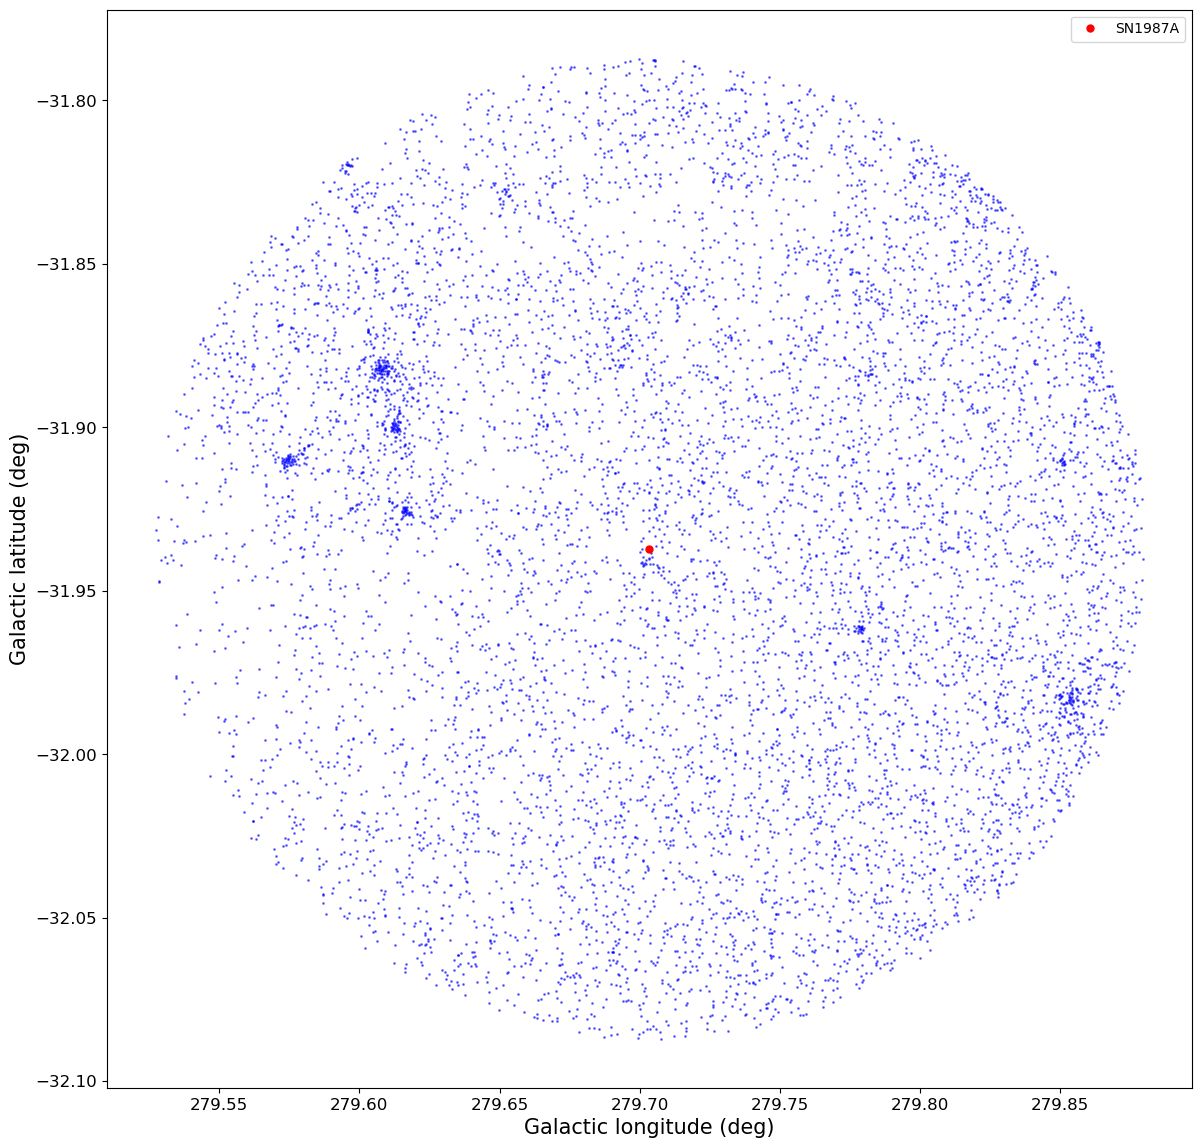

In [41]:
fig, ax = plt.subplots(1, figsize=(14, 14))

print(
    (np.amax(runaways_raw.l) - np.amin(runaways_raw.l)) /
    (np.amax(runaways_raw.b) - np.amin(runaways_raw.b))
)

ax.plot(runaways_raw.l, runaways_raw.b, 'bo', ms=1., alpha=0.5)

# Mark SN1987A
ax.plot(center_l, center_b, 'ro', ms=5., label='SN1987A')

ax.tick_params(labelsize=12)
ax.set_xlabel('Galactic longitude (deg)', fontsize=15)
ax.set_ylabel('Galactic latitude (deg)', fontsize=15)
ax.legend()

plt.show()

In [42]:
from pathlib import Path
import pandas as pd
import numpy as np

# Folders
input_files_dir = Path("input_files")
output_dir = Path("output_files")
output_dir.mkdir(exist_ok=True)

# Load raw Gaia table if it is not already in memory
# Prefer the raw input file. If that does not exist, use the saved zero-point/raw output.
if "runaways_raw" not in globals():
    if (input_files_dir / "SN1987A_raw.csv").exists():
        runaways_raw = pd.read_csv(input_files_dir / "SN1987A_raw.csv", low_memory=False)
        print("Loaded:", input_files_dir / "SN1987A_raw.csv")
    elif (output_dir / "SN1987A_raw_zp.csv").exists():
        runaways_raw = pd.read_csv(output_dir / "SN1987A_raw_zp.csv", low_memory=False)
        print("Loaded:", output_dir / "SN1987A_raw_zp.csv")
    else:
        raise FileNotFoundError("Could not find SN1987A_raw.csv or SN1987A_raw_zp.csv")

# Make sure column names are clean
runaways_raw.columns = runaways_raw.columns.str.strip()

# Gaia quality-cut parameters
max_ruwe = 1.4
max_ipd_frac_multi_peak = 10.0
min_visibility_periods_used = 10
max_duplicated_source = 0.5
max_ipd_gof_harmonic_amplitude = 0.15

print("Raw Gaia rows:", len(runaways_raw))
print("Quality-cut parameters defined.")

Raw Gaia rows: 8942
Quality-cut parameters defined.


In [43]:
runaways_filter = runaways_raw.copy()
runaways = gdf_nozp.gaia_filtering(runaways_filter, max_ruwe, max_ipd_frac_multi_peak, min_visibility_periods_used, 
                              max_duplicated_source, max_ipd_gof_harmonic_amplitude)


After excluding on ruwe: 7921 sources left
After excluding on ipd_frac_multi_peak: 7570 sources left
After excluding on visibility_periods_used: 7518 sources left
After excluding on duplicated_source: 7504 sources left
After excluding on ipd_gof_harmonic_amplitude: 7474 sources left


# Filter on parallax

In [44]:
print(len(runaways))
runaways = runaways[runaways.parallax_error < 0.05]
runaways = runaways[runaways.parallax - 3*runaways.parallax_error < 1/49.59]
print(len(runaways))

7474
1061


# Selection summary and candidate table

In [47]:
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord, SkyOffsetFrame

# ------------------------------------------------------------
# Selection summary and candidate table 
# ------------------------------------------------------------

# Constants
D_LMC_kpc = 49.59
D_LMC_pc = D_LMC_kpc * 1000
masyr_to_kms = 4.74047 * D_LMC_kpc

# SN1987A position and proper motion
sn87a = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")
pmra_87a = 1.60
pmdec_87a = 0.44

# copies so the table is reproducible
raw_sample = runaways_raw.copy()
clean_sample = runaways.copy()

def add_sn1987a_columns(table):
    """ 
    Add projected separation from SN1987A and velocity difference
    from the adopted SN1987A proper motion.
    """
    table = table.copy()
    table.columns = table.columns.str.strip()

    coords = SkyCoord(
        ra=table["ra"].values * u.deg,
        dec=table["dec"].values * u.deg,
        frame="icrs"
    )

    frame_87a = SkyOffsetFrame(origin=sn87a)
    offsets = coords.transform_to(frame_87a)

    table["x_pc"] = offsets.lon.to_value(u.rad) * D_LMC_pc
    table["y_pc"] = offsets.lat.to_value(u.rad) * D_LMC_pc
    table["sep_87a_pc"] = np.sqrt(table["x_pc"]**2 + table["y_pc"]**2)
    # Proper-motion and velocity difference from SN 1987A
    table["dpm_to_sn87a_masyr"] = np.hypot(
        table["pmra"] - pmra_87a,
        table["pmdec"] - pmdec_87a
    )

    table["dv_to_sn87a_kms"] = (
        masyr_to_kms * table["dpm_to_sn87a_masyr"]
    )

    return table

raw_sample = add_sn1987a_columns(raw_sample)
clean_sample = add_sn1987a_columns(clean_sample)

# Local LMC median, estimated from the cleaned sample within 100 pc
local_for_median = clean_sample[clean_sample["sep_87a_pc"] < 100].copy()

# sanity check for projected separation
# Sanity check: does the cleaned parent catalogue cover at least 100 pc?
if "sep_87a_pc" not in clean_sample.columns:
    raise KeyError(
        "'sep_87a_pc' is missing from clean_sample. "
        "Run the projected-separation calculation first."
    )

max_sep = clean_sample["sep_87a_pc"].max()
print(f"Maximum separation covered: {max_sep:.1f} pc")

if max_sep < 100:
    raise ValueError(
        "This catalogue does not cover a complete 100 pc radius. "
        "Use the broad catalogue or rerun the Gaia query with "
        "radius_deg >= 0.12."
    )

# Local LMC sample within 100 pc
local_for_median = clean_sample[
    clean_sample["sep_87a_pc"] < 100
    ].copy()

print(f"Sources within 100 pc: {len(local_for_median)}")
if len(local_for_median) < 20:
    local_for_median = clean_sample.copy()

pmra_local = np.nanmedian(local_for_median["pmra"])
pmdec_local = np.nanmedian(local_for_median["pmdec"])

# Proper-motion and velocity difference from the local LMC median
clean_sample["dpm_to_local_masyr"] = np.hypot(
    clean_sample["pmra"] - pmra_local,
    clean_sample["pmdec"] - pmdec_local
)

clean_sample["dv_to_local_kms"] = (
        masyr_to_kms * clean_sample["dpm_to_local_masyr"]
)
print("Local median PMRA*:", pmra_local)
print("Local median PMDec:", pmdec_local)

# ------------------------------------------------------------
# Defining selections
# ------------------------------------------------------------

within_100pc = clean_sample["sep_87a_pc"] < 100
within_30pc = clean_sample["sep_87a_pc"] < 30

comoving_100pc_30kms = (
        (clean_sample["sep_87a_pc"] < 100) &
        (clean_sample["dv_to_sn87a_kms"] < 30)
)

comoving_30pc_20kms = (
        (clean_sample["sep_87a_pc"] < 30) &
        (clean_sample["dv_to_sn87a_kms"] < 20)
)

high_residual_50kms = clean_sample["dv_to_sn87a_kms"] > 50
# ------------------------------------------------------------
# Cut summary table
# ------------------------------------------------------------

cut_summary = pd.DataFrame([
    {
        "selection": "all Gaia sources after query",
        "n_stars": len(raw_sample)
    },
    {
        "selection": "after Gaia quality + parallax cuts",
        "n_stars": len(clean_sample)
    },
    {
        "selection": "within 100 pc of SN1987A",
        "n_stars": int(within_100pc.sum())
    },
    {
        "selection": "within 30 pc of SN1987A",
        "n_stars": int(within_30pc.sum())
    },
    {
        "selection": "within 100 pc and <30 km/s from SN1987A PM",
        "n_stars": int(comoving_100pc_30kms.sum())
    },
    {
        "selection": "within 30 pc and <20 km/s from SN1987A PM",
        "n_stars": int(comoving_30pc_20kms.sum())
    },
    {
        "selection": ">50 km/s from SN1987A PM",
        "n_stars": int(high_residual_50kms.sum())
    },
])

cut_summary["fraction_of_query"] = cut_summary["n_stars"] / len(raw_sample)

display(cut_summary)

# Save table 
cut_summary.to_csv(output_dir / "SN1987A_cut_summary.csv", index=False)

# 
#  LaTeX version for direct use in thesis
cut_summary_latex = cut_summary.copy()
cut_summary_latex["fraction_of_query"] = cut_summary_latex["fraction_of_query"].map(lambda x: f"{x:.3f}")

cut_summary_latex.to_latex(
    output_dir / "SN1987A_cut_summary.tex",
    index=False,
    caption="Summary of Gaia DR3 selection cuts around SN1987A.",
    label="tab:sn1987a_cut_summary"
)

# ------------------------------------------------------------
# Candidate table
# ------------------------------------------------------------

clean_sample["local_comoving_30pc_20kms"] = comoving_30pc_20kms
clean_sample["local_comoving_100pc_30kms"] = comoving_100pc_30kms
clean_sample["high_residual_50kms"] = high_residual_50kms

clean_sample["candidate_class"] = "other"

clean_sample.loc[
    high_residual_50kms,
    "candidate_class"
] = "high_residual_50kms"

clean_sample.loc[
    comoving_100pc_30kms,
    "candidate_class"
] = "local_comoving_100pc_30kms"

clean_sample.loc[
    comoving_30pc_20kms,
    "candidate_class"
] = "local_comoving_30pc_20kms"

candidate_table = clean_sample[
    comoving_30pc_20kms |
    comoving_100pc_30kms |
    high_residual_50kms
    ].copy()

candidate_columns = [
    "source_id",
    "ra",
    "dec",
    "phot_g_mean_mag",
    "bp_rp",
    "pmra",
    "pmdec",
    "pmra_error",
    "pmdec_error",
    "ruwe",
    "x_pc",
    "y_pc",
    "sep_87a_pc",
    "dpm_to_sn87a_masyr",
    "dv_to_sn87a_kms",
    "dpm_to_local_masyr",
    "dv_to_local_kms",
    "local_comoving_30pc_20kms",
    "local_comoving_100pc_30kms",
    "high_residual_50kms",
    "candidate_class",
]

candidate_columns = [col for col in candidate_columns if col in candidate_table.columns]

candidate_table = candidate_table[candidate_columns].sort_values(
    by=["candidate_class", "sep_87a_pc", "dv_to_sn87a_kms"]
)

display(candidate_table.head(20))

candidate_table.to_csv(output_dir / "SN1987A_candidate_table.csv", index=False)

# full table with cleaned plots, perchance useful in the futute
clean_sample.to_csv(output_dir / "SN1987A_cands_with_selection_flags.csv", index=False)

print("Saved:")
print(output_dir / "SN1987A_cut_summary.csv")
print(output_dir / "SN1987A_cut_summary.tex")
print(output_dir / "SN1987A_candidate_table.csv")
print(output_dir / "SN1987A_cands_with_selection_flags.csv")

Maximum separation covered: 129.8 pc
Sources within 100 pc: 648
Local median PMRA*: 1.6743033157703813
Local median PMDec: 0.5571585281202223


,selection,n_stars,fraction_of_query
0,all Gaia sources after query,8942,1.000000
1,after Gaia quality + parallax cuts,1061,0.118654
2,within 100 pc of SN1987A,648,0.072467
3,within 30 pc of SN1987A,59,0.006598
4,within 100 pc and <30 km/s from SN1987A PM,172,0.019235
5,within 30 pc and <20 km/s from SN1987A PM,3,0.000335
6,>50 km/s from SN1987A PM,422,0.047193


,source_id,ra,dec,phot_g_mean_mag,bp_rp,pmra,pmdec,pmra_error,pmdec_error,ruwe,...,y_pc,sep_87a_pc,dpm_abs_87a_masyr,dv_abs_87a_kms,dpm_vs_local_masyr,dv_vs_local_kms,local_comoving_30pc_20kms,local_comoving_100pc_30kms,high_residual_50kms,candidate_class
1396,4657668007030021248,83.867773,-69.269970,15.773073,0.251451,1.324677,0.589892,0.049405,0.043152,1.142589,...,-0.186804,0.399957,0.313481,73.693194,0.351156,82.549660,False,False,True,high_residual_50kms
2190,4657668075746867584,83.853870,-69.268200,15.859596,-0.101064,1.453357,0.609643,0.050541,0.047101,0.987554,...,1.344500,4.130746,0.224239,52.713984,0.227095,53.385410,False,False,True,high_residual_50kms
2620,4657668080079330048,83.835070,-69.261018,16.920755,1.722948,2.109048,0.635898,0.080630,0.069402,0.957565,...,7.558127,12.272698,0.545441,128.222260,0.441818,103.862484,False,False,True,high_residual_50kms
1770,4657667942640388352,83.826788,-69.275180,13.216023,1.933559,1.652132,0.651707,0.018281,0.016824,1.105382,...,-4.700627,13.073836,0.218032,51.254845,0.097114,22.829492,False,False,True,high_residual_50kms
1312,4657668045719599744,83.896270,-69.258120,16.284328,1.874653,1.840797,0.514940,0.054852,0.047745,1.022528,...,10.067059,13.562968,0.252189,59.284504,0.171763,40.378005,False,False,True,high_residual_50kms
1392,4657668041387134592,83.902849,-69.259996,16.401098,2.028217,1.621117,0.675965,0.057392,0.051177,0.985876,...,8.442514,13.949506,0.236908,55.692291,0.130168,30.599960,False,False,True,high_residual_50kms
1908,4657668045719588608,83.876217,-69.250723,16.784159,1.922768,1.650464,0.884640,0.072090,0.062053,1.025287,...,16.470705,16.731610,0.447494,105.196956,0.328348,77.188002,False,False,True,high_residual_50kms
1773,4657668732914362368,83.811435,-69.269888,15.732141,2.337147,1.800101,0.580553,0.045332,0.041316,1.099151,...,-0.123508,16.906342,0.244531,57.484365,0.127954,30.079467,False,False,True,high_residual_50kms
1048,4657668045719603840,83.914978,-69.259098,15.858542,1.510490,1.652687,1.029023,0.042359,0.036601,0.988777,...,9.216441,17.454629,0.591375,139.020304,0.472359,111.042184,False,False,True,high_residual_50kms
7093,4657667873920931456,83.868477,-69.289949,16.375343,-0.160824,1.780470,0.574806,0.058847,0.049261,1.001431,...,-17.478875,17.488131,0.225260,52.954100,0.107623,25.300104,False,False,True,high_residual_50kms


Saved:
output_files\SN1987A_cut_summary.csv
output_files\SN1987A_cut_summary.tex
output_files\SN1987A_candidate_table.csv
output_files\SN1987A_cands_with_selection_flags.csv


The full SN1987A_candidate_table.csv is too big for the main text. Making a small version with only the most useful columns and only the strongest candidates:

In [48]:
# Small candidate table for thesis / Overleaf

thesis_candidates = candidate_table[
    candidate_table["candidate_class"].isin([
        "local_comoving_30pc_20kms",
        "local_comoving_100pc_30kms"
    ])
].copy()

# Sort strongest candidates first:
# nearby stars first, then smallest velocity difference
thesis_candidates = thesis_candidates.sort_values(
    by=["sep_87a_pc", "dv_to_sn87a_kms"]
)

# Keep only a manageable number for the main thesis
thesis_candidates = thesis_candidates.head(15)

# Select only thesis-relevant columns
thesis_candidates = thesis_candidates[
    [
        "source_id",
        "phot_g_mean_mag",
        "bp_rp",
        "sep_87a_pc",
        "dv_to_sn87a_kms",
        "dv_to_local_kms",
        "candidate_class"
    ]
].copy()

# Rename columns for nicer LaTeX table
thesis_candidates = thesis_candidates.rename(columns={
    "source_id": "Gaia DR3 source ID",
    "phot_g_mean_mag": "$G$",
    "bp_rp": "$G_{BP}-G_{RP}$",
    "sep_87a_pc": "$d_{\\mathrm{SN}}$ [pc]",
    "dv_to_sn87a_kms": "$\\Delta v_{\\mathrm{SN}}$ [km s$^{-1}$]",
    "dv_to_local_kms": "$\\Delta v_{\\mathrm{local}}$ [km s$^{-1}$]",
    "candidate_class": "Candidate class"
})

# Round numerical columns
for col in ["$G$", "$G_{BP}-G_{RP}$", "$d_{\\mathrm{SN}}$ [pc]",
            "$\\Delta v_{\\mathrm{SN}}$ [km s$^{-1}$]",
            "$\\Delta v_{\\mathrm{local}}$ [km s$^{-1}$]"]:
    thesis_candidates[col] = thesis_candidates[col].astype(float).round(2)

display(thesis_candidates)

# Save CSV and LaTeX versions
thesis_candidates.to_csv(output_dir / "SN1987A_candidate_table_thesis.csv", index=False)

thesis_candidates.to_latex(
    output_dir / "SN1987A_candidate_table_thesis.tex",
    index=False,
    escape=False,
    caption="Strongest local co-moving Gaia DR3 candidate stars near SN 1987A.",
    label="tab:sn1987a_candidate_table",
    column_format="lrrrrrl"
)

print("Saved:")
print(output_dir / "SN1987A_candidate_table_thesis.csv")
print(output_dir / "SN1987A_candidate_table_thesis.tex")

,Gaia DR3 source ID,$G$,$G_{BP}-G_{RP}$,$d_{\mathrm{SN}}$ [pc],$\Delta v_{\mathrm{SN}}$ [km s$^{-1}$],$\Delta v_{\mathrm{local}}$ [km s$^{-1}$],Candidate class
915,4657668080079343104,14.98,-0.05,0.69,29.35,3.75,local_comoving_100pc_30kms
2115,4657668011359871104,15.96,-0.21,3.63,17.85,44.34,local_comoving_30pc_20kms
7620,4657667977000128512,16.89,-0.17,6.81,26.53,9.51,local_comoving_100pc_30kms
8663,4657668011359876352,16.70,-0.14,9.31,26.41,10.85,local_comoving_100pc_30kms
8733,4657668045719604608,16.36,-0.10,13.91,0.29,32.43,local_comoving_30pc_20kms
2510,4657667904012573312,16.55,1.63,14.53,20.79,17.53,local_comoving_100pc_30kms
6737,4657667839561179136,16.08,0.02,18.32,25.48,8.45,local_comoving_100pc_30kms
595,4657668492396180736,14.61,0.03,23.52,25.77,12.73,local_comoving_100pc_30kms
620,4657662823037961728,15.75,1.40,26.40,24.89,23.81,local_comoving_100pc_30kms
1078,4657668492396177280,15.99,-0.02,27.91,20.69,34.39,local_comoving_100pc_30kms


Saved:
output_files\SN1987A_candidate_table_thesis.csv
output_files\SN1987A_candidate_table_thesis.tex


# Save the runaway candidates

In [49]:
runaways.to_csv(output_dir / "SN1987A_cands.csv", index=False)
runaways_raw.to_csv(output_dir / "SN1987A_raw_zp.csv", index=False)

finished the first stage: generating / filtering the Gaia catalogue used as input for the runaway search; checking what files the notebook created or updated:

In [50]:
from pathlib import Path
import pandas as pd

for folder in ["input_files", "output_files"]:
    print("\n" + folder)
    for f in sorted(Path(folder).glob("*.csv")):
        print(f"{f.name:35s} {f.stat().st_size/1e6:8.2f} MB")


input_files
SN1987A_broad_raw_1deg.csv            128.34 MB
SN1987A_gaia_test.csv                   0.25 MB
SN1987A_raw.csv                        11.24 MB

output_files
SN1987A_broad_clean_1deg.csv           95.56 MB
SN1987A_candidate_table.csv             0.19 MB
SN1987A_candidate_table_thesis.csv      0.00 MB
SN1987A_cands.csv                       1.81 MB
SN1987A_cands_with_selection_flags.csv     1.98 MB
SN1987A_cut_summary.csv                 0.00 MB
SN1987A_local_comoving_candidates_updated.csv     0.02 MB
SN1987A_raw_zp.csv                     14.22 MB
SN1987A_strict_candidates.csv           0.01 MB
SN1987A_strict_candidates_characterised.csv     0.01 MB


inspecting the main output tables

In [51]:
for fname in [
    "input_files/R136_runaways_raw.csv",
    "output_files/runaways_cands.csv",
    "output_files/runaways_mcmc.csv",
    "output_files/runaways_outliers_mcmc.csv",
    "output_files/runaways_raw_zp_1deg.csv",
]:
    f = Path(fname)
    if f.exists():
        df = pd.read_csv(f, nrows=5)
        print("\n", fname)
        print("columns:", list(df.columns[:15]), "...")
        print(df.head())

cleaner overview:

In [52]:
from pathlib import Path
import pandas as pd

for fname in [
    "output_files/runaways_raw_zp_1deg.csv",
    "output_files/runaways_cands.csv",
    "output_files/runaways_mcmc.csv",
    "output_files/runaways_outliers_mcmc.csv",
]:
    f = Path(fname)
    if f.exists():
        df = pd.read_csv(f)
        print(fname)
        print("shape:", df.shape)
        print("first columns:", list(df.columns[:20]))
        print()

In [54]:
cands_file = output_dir / "SN1987A_cands.csv"
D_LMC_KPC = 49.59

if not cands_file.exists():
    raise FileNotFoundError(
        "Missing output_files/SN1987A_cands.csv. "
        "First run the cleaned Gaia-candidate notebook."
    )

df = pd.read_csv(cands_file, low_memory=False)
df.columns = df.columns.str.strip()

coords = SkyCoord(df["ra"].values*u.deg, df["dec"].values*u.deg, frame="icrs")
sep_deg = sn87a.separation(coords).deg
sep_pc = sn87a.separation(coords).radian * D_LMC_KPC * 1000.0

df["sep_87a_deg"] = sep_deg
df["sep_87a_pc"] = sep_pc

print("Rows:", len(df))
print("Max separation from SN1987A [deg]:", np.nanmax(df["sep_87a_deg"]))
print("Max separation from SN1987A [pc]:", np.nanmax(df["sep_87a_pc"]))
print("Median RA/Dec:", np.nanmedian(df["ra"]), np.nanmedian(df["dec"]))

# For the 0.10 deg run, max separation should be about 0.10 deg.
# Leave tolerance because later you may intentionally run 0.25 or 0.50 deg.
if np.nanmax(df["sep_87a_deg"]) > 0.55:
    raise ValueError(
        "This candidate file is too wide for the current SN1987A runs. "
        "It may be an R136/raw file or a 1-2 degree test file. "
        "Regenerate SN1987A_cands.csv from SN1987A_raw.csv."
    )

df.to_csv(output_dir / "SN1987A_cands_checked.csv", index=False)
df.head()

Rows: 1061
Max separation from SN1987A [deg]: 0.14996308569140374
Max separation from SN1987A [pc]: 129.79436675154582
Median RA/Dec: 83.93517986002657 -69.27068752708914


C:\Users\bukow\AppData\Local\Temp\ipykernel_33888\2036500388.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sep_87a_deg"] = sep_deg
C:\Users\bukow\AppData\Local\Temp\ipykernel_33888\2036500388.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sep_87a_pc"] = sep_pc


,solution_id,designation,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,...,l_pml_corr,l_pmb_corr,b_parallax_corr,b_pml_corr,b_pmb_corr,parallax_pml_corr,parallax_pmb_corr,pml_pmb_corr,sep_87a_deg,sep_87a_pc
0,1636148068921376768,Gaia DR3 4658413548948000000,1120564123,2016.0,83.446815,0.020848,-69.257491,0.022708,0.027288,0.020543,...,-0.505392,0.075813,-0.113840,0.066658,0.069223,0.128134,0.180835,-0.020942,0.149144,129.085480
1,1636148068921376768,Gaia DR3 4658413445868795520,1338073590,2016.0,83.448733,0.042319,-69.267606,0.044771,0.014902,0.042409,...,-0.467990,0.056614,-0.100527,0.058029,0.058712,0.163755,0.232902,-0.035449,0.147941,128.044058
2,1636148068921376768,Gaia DR3 4658413583276517120,467715710,2016.0,83.454159,0.049917,-69.252358,0.054356,-0.012500,0.049518,...,-0.484760,0.094477,-0.154666,0.065754,0.068882,0.144882,0.131997,-0.027979,0.147088,127.306206
3,1636148068921376768,Gaia DR3 4658413544623814016,470368822,2016.0,83.458082,0.036758,-69.261688,0.039534,0.037062,0.036929,...,-0.470066,0.055810,-0.065331,0.056045,0.055838,0.162371,0.219651,-0.043741,0.144860,125.377841
4,1636148068921376768,Gaia DR3 4658413411509083904,1697285174,2016.0,83.463439,0.048876,-69.286307,0.053037,-0.139270,0.049895,...,-0.478556,0.114919,-0.093611,0.090452,0.097324,0.282108,0.154870,-0.049883,0.143615,124.300213



raw Gaia query

has proper motions

RUWE < 1.4

visibility_periods_used >= 10

not duplicated_source

IPD cuts passed

parallax consistent with LMC / not foreground

within 100 pc of SN1987A

within 50 pc of SN1987A

dv_local_resid < 30 km/s

dv_local_resid < 20 km/s

KeyError: 'dv_local_resid_kms'

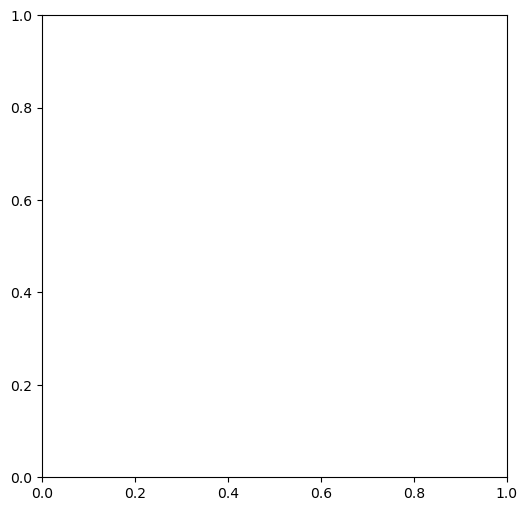

In [55]:
fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    clean_sample["bp_rp"],
    clean_sample["phot_g_mean_mag"],
    c=clean_sample["dv_to_sn87a_kms"],
    vmin=0,
    vmax=80,
    cmap="plasma",
    s=10,
    alpha=0.6,
    edgecolors="none"
)

cand = clean_sample[
    (clean_sample["sep_87a_pc"] < 100) &
    (clean_sample["dv_to_sn87a_kms"] < 30)
    ].copy()

ax.scatter(
    cand["bp_rp"],
    cand["phot_g_mean_mag"],
    facecolors="none",
    edgecolors="black",
    s=45,
    label=r"$d<100$ pc and $\Delta v_{\rm 87A}<30$ km s$^{-1}$"
)

ax.invert_yaxis()
ax.set_xlabel(r"$G_{\rm BP}-G_{\rm RP}$")
ax.set_ylabel(r"$G$")
ax.set_title("Gaia CMD coloured by velocity difference from SN 1987A")
ax.legend(fontsize=8)

cb = plt.colorbar(sc, ax=ax)
cb.set_label(
    r"Velocity difference from SN 1987A, "
    r"$\Delta v_{\rm 87A}$ [km s$^{-1}$]"
)

plt.tight_layout()
plt.show()